# Homework 3

**Coverage:** Lectures 11–12  
**Due:** Sunday, September 20, 2026, 11:59 p.m. ET  
**Total:** 100 points

## What this homework practices

| Lecture | Assessed ideas |
|:--|:--|
| 11 — Selecting prior information | Translate support, mean, and variance information into a maximum-entropy Gaussian prior; distinguish prior location from prior concentration; test sensitivity to alternative prior information. |
| 12 — Analytical Bayesian inference | Derive an analytical posterior, quantify posterior uncertainty, design a sample size, form posterior-predictive distributions, simulate replicated data, and make a probability-based decision. |

Useful course-book pages are [Lecture 11: selecting prior
information](https://predictivesciencelab.github.io/data-analytics-se/lecture11/reading-11.html),
[continuous maximum-entropy
examples](https://predictivesciencelab.github.io/data-analytics-se/lecture11/hands-on-11.3.html),
[Lecture 12: analytical Bayesian
inference](https://predictivesciencelab.github.io/data-analytics-se/lecture12/reading-12.html),
[credible
intervals](https://predictivesciencelab.github.io/data-analytics-se/lecture12/hands-on-12.2.html),
and [posterior-predictive
distributions](https://predictivesciencelab.github.io/data-analytics-se/lecture12/hands-on-12.4.html).

Normal–Normal and Gamma–Poisson conjugacy are used as guided extensions of
Lecture 12. Every required definition and parameterization is supplied
below.

## Instructions

- Complete this notebook in Google Colab or another fresh Python environment.
- Problem 1 is a short hand-calculation problem. Show the important
  derivation and interpretation steps in Markdown/LaTeX, or insert one clearly
  legible image of your handwritten work. If you insert an image, accompany it
  with a descriptive alternative-text summary in the response cell and type
  all final mathematical results there. No code is needed.
- Problem 2 is a scaffolded scientific-computing study. Use the supplied
  random seeds and do not delete setup, helper, or data-credit cells.
- The setup cell downloads and verifies the frozen course data automatically.
  Do not upload or replace the CSV, and do not query the live USGS catalog.
- Do not mount Google Drive or use Drive/absolute data paths. Saving your
  Colab notebook copy in Drive is fine. Do not install additional packages.
- Label plots and include units. Report numerical answers to at least four
  significant digits unless instructed otherwise.
- Follow the current course and Brightspace submission policies.

## Student details

- **First name:**
- **Last name:**
- **Purdue email:**


In [2]:
from io import BytesIO
from pathlib import Path
import hashlib
import urllib.error
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 53903
sns.set_theme(style="ticks", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.constrained_layout.use"] = True
np.set_printoptions(precision=6, suppress=True)

DATA_NAME = "southern-california-baja-earthquakes-1900-2025.csv"
EXPECTED_DATA_SHA256 = (
    "a4e7fb0d2a99fc81cf0f309e13a853b6025413e84d61ab82f18cc8c43ec37072"
)
COURSE_DATA_URL = (
    "https://predictivesciencelab.github.io/data-analytics-se/_downloads/"
    "0df04c34eed724ea5eaaf5e918b4496c/"
    "southern-california-baja-earthquakes-1900-2025.csv"
)
LOCAL_DATA_CANDIDATES = (
    Path(DATA_NAME),
    Path("../data/homework") / DATA_NAME,
    Path("lecturebook/data/homework") / DATA_NAME,
)


def sha256_bytes(payload):
    '''Return the hexadecimal SHA-256 digest of a byte string.'''
    return hashlib.sha256(payload).hexdigest()


def load_frozen_course_data():
    '''Load the hash-verified snapshot locally or from the course repository.'''
    rejected = []
    for candidate in LOCAL_DATA_CANDIDATES:
        if candidate.is_file():
            payload = candidate.read_bytes()
            digest = sha256_bytes(payload)
            if digest == EXPECTED_DATA_SHA256:
                return payload, f"verified local course file: {candidate}"
            rejected.append(f"{candidate} (SHA-256 {digest})")

    request = urllib.request.Request(
        COURSE_DATA_URL,
        headers={"User-Agent": "ME539-course-data/2026"},
    )
    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            payload = response.read()
    except (urllib.error.URLError, TimeoutError) as exc:
        rejected_text = (
            f" Rejected local files: {', '.join(rejected)}."
            if rejected
            else ""
        )
        raise RuntimeError(
            "Could not download the frozen Homework 3 course data. "
            "Check the internet connection and rerun this cell."
            + rejected_text
        ) from exc

    digest = sha256_bytes(payload)
    if digest != EXPECTED_DATA_SHA256:
        raise ValueError(
            "Downloaded bytes do not match the frozen course snapshot: "
            f"expected {EXPECTED_DATA_SHA256}, received {digest}."
        )
    return payload, f"verified published course file: {COURSE_DATA_URL}"


DATA_BYTES, DATA_SOURCE = load_frozen_course_data()
print(f"Loaded {len(DATA_BYTES)} verified bytes from {DATA_SOURCE}.")


Loaded 1954 verified bytes from verified published course file: https://predictivesciencelab.github.io/data-analytics-se/_downloads/0df04c34eed724ea5eaaf5e918b4496c/southern-california-baja-earthquakes-1900-2025.csv.


## Problem 1 — Maximum entropy and Bayesian sensor calibration (25 points)

A sensor's **calibration residual** is its reported value minus a known
reference value. Let $b$, measured in millivolts (mV), denote the sensor's
unknown but fixed signed zero offset. Before collecting calibration
measurements, the available engineering information is

$$
b\in\mathbb{R},
\qquad
\mathbb{E}[b]=b_0,
\qquad
\mathbb{V}[b]=\tau_0^2.
$$

Assume $\tau_0>0$.

Support and moments do not uniquely determine a prior distribution. Once
the variable and reference density are specified, the maximum-entropy
principle selects the feasible distribution that introduces the least
additional structure beyond the stated information.

### 1.1 Derive the maximum-entropy prior (7 points)

Take the reference density to be $q(b)=1$ relative to Lebesgue measure—that
is, ordinary integration with respect to $db$—in the stated mV coordinate.
Equivalently, write the variance constraint as the second-moment constraint

$$
\mathbb{E}[b^2]=b_0^2+\tau_0^2.
$$

Lecture 11's maximum-entropy result gives a density of the form

$$
\pi(b)
=
\frac{1}{Z}
\exp\left(\eta_1b+\eta_2b^2\right),
\qquad b\in\mathbb{R},
$$

where $Z$ is the normalization constant.

1. Explain why $\eta_2<0$ is required. **(1 point)**
2. Complete the square and use the two moment constraints to determine
   $\eta_1$ and $\eta_2$. **(4 points)**
3. Determine $Z$ and identify the resulting named prior distribution.
   **(2 points)**

You may use

$$
\int_{-\infty}^{\infty}
\exp\left[-\frac{a}{2}(x-c)^2\right]\,dx
=
\sqrt{\frac{2\pi}{a}},
\qquad a>0.
$$


### 1.1 Derive the maximum-entropy prior

We are given the prior information

$$
b\in\mathbb R,\qquad E[b]=b_0,\qquad V[b]=\tau_0^2,
$$

with $\tau_0>0$. Since

$$
V[b]=E[b^2]-E[b]^2,
$$

the second-moment constraint is

$$
\boxed{E[b^2]=b_0^2+\tau_0^2}.
$$

The maximum-entropy density is given in the form

$$
\pi(b)=\frac{1}{Z}\exp(\eta_1b+\eta_2b^2),\qquad b\in\mathbb R.
$$

#### 1. Why must $\eta_2<0$?

Because the support is the entire real line, the density must be integrable:

$$
\int_{-\infty}^{\infty}\exp(\eta_1b+\eta_2b^2)\,db<\infty.
$$

For large $|b|$, the quadratic term $\eta_2b^2$ dominates. If $\eta_2>0$, then $\exp(\eta_2b^2)$ grows without bound and the integral diverges. If $\eta_2=0$, the remaining exponential term is also not integrable over the entire real line. Therefore,

$$
\boxed{\eta_2<0}.
$$

#### 2. Determine $\eta_1$ and $\eta_2$

Complete the square in the exponent:

$$
\eta_1b+\eta_2b^2
=
\eta_2\left(b+\frac{\eta_1}{2\eta_2}\right)^2
-\frac{\eta_1^2}{4\eta_2}.
$$

We want this density to have mean $b_0$ and variance $\tau_0^2$. The exponent of a Gaussian distribution with these parameters is

$$
-\frac{(b-b_0)^2}{2\tau_0^2}.
$$

Expanding this Gaussian exponent gives

$$
-\frac{(b-b_0)^2}{2\tau_0^2}
=
-\frac{b^2}{2\tau_0^2}
+\frac{b_0}{\tau_0^2}b
-\frac{b_0^2}{2\tau_0^2}.
$$

Comparing the coefficients of $b^2$ and $b$ with $\eta_2b^2+\eta_1b$, we obtain

$$
\boxed{\eta_2=-\frac{1}{2\tau_0^2},\qquad \eta_1=\frac{b_0}{\tau_0^2}}.
$$

Therefore,

$$
\eta_1b+\eta_2b^2
=
-\frac{(b-b_0)^2}{2\tau_0^2}
+\frac{b_0^2}{2\tau_0^2}.
$$

#### 3. Determine the normalization constant $Z$

By definition,

$$
Z=\int_{-\infty}^{\infty}\exp(\eta_1b+\eta_2b^2)\,db.
$$

Substituting the completed-square form,

$$
Z=
\exp\left(\frac{b_0^2}{2\tau_0^2}\right)
\int_{-\infty}^{\infty}
\exp\left[-\frac{(b-b_0)^2}{2\tau_0^2}\right]\,db.
$$

Using the Gaussian integral

$$
\int_{-\infty}^{\infty}
\exp\left[-\frac{(x-c)^2}{2\tau_0^2}\right]\,dx
=
\sqrt{2\pi\tau_0^2},
$$

we obtain

$$
\boxed{
Z=
\sqrt{2\pi\tau_0^2}
\exp\left(\frac{b_0^2}{2\tau_0^2}\right)
}.
$$

Substituting $Z$, $\eta_1$, and $\eta_2$ into the density gives

$$
\pi(b)
=
\frac{1}{\sqrt{2\pi\tau_0^2}}
\exp\left[-\frac{(b-b_0)^2}{2\tau_0^2}\right].
$$

Thus, the maximum-entropy prior is

$$
\boxed{b\sim\mathcal N(b_0,\tau_0^2)}.
$$

Here $b_0$ determines the location of the prior, while $\tau_0^2$ determines its spread or concentration. A larger $\tau_0^2$ corresponds to a less concentrated prior, while a smaller $\tau_0^2$ corresponds to a more concentrated prior.

### 1.2 Derive the analytical posterior (10 points)

Suppose the calibration residuals $Y_1,\ldots,Y_N$ are conditionally
independent given $b$ and satisfy

$$
Y_i\mid b\sim N(b,\sigma^2),
\qquad i=1,\ldots,N,
$$

where $\sigma>0$, $N\geq1$, and the measurement-noise variance $\sigma^2$ is
known. Let $y_{1:N}=(y_1,\ldots,y_N)$ denote the observed residuals, and
define

$$
\bar y=\frac{1}{N}\sum_{i=1}^N y_i.
$$

1. Write the likelihood as a function of $b$, retaining all factors that
   depend on $b$. **(2 points)**
2. Starting from Bayes' rule,

   $$
   p(b\mid y_{1:N})
   \propto
   p(y_{1:N}\mid b)\pi(b),
   $$

   complete the square and show that

   $$
   b\mid y_{1:N}\sim N(b_N,v_N).
   $$

   Derive explicit expressions for $b_N$ and $v_N$. **(5 points)**
3. **Precision** means reciprocal variance. Rewrite $b_N$ as a weighted
   average of $b_0$ and $\bar y$ whose weights are determined by prior
   precision and data precision. Verify that the weights sum to one and
   interpret them. **(2 points)**
4. A prior family is **conjugate** to a likelihood when the posterior belongs
   to the same distribution family as the prior. Explain why this update is
   conjugate. **(1 point)**

You may use

$$
\sum_{i=1}^N(y_i-b)^2
=
\sum_{i=1}^N(y_i-\bar y)^2
+
N(b-\bar y)^2.
$$

Leave the posterior in terms of $N$ and $\bar y$; no numerical observations
are required.


## 1.2 Analytical posterior

We have the measurement model

$$
Y_i\mid b\sim\mathcal N(b,\sigma^2),
\qquad i=1,\ldots,N.
$$

This means that, given the sensor offset $b$, each measurement has mean $b$ and variance $\sigma^2$.

Therefore, the probability density of one measurement is

$$
p(y_i\mid b)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(y_i-b)^2}{2\sigma^2}
\right).
$$

Since the measurements are conditionally independent, the likelihood is

$$
p(\mathbf y\mid b)
=
\prod_{i=1}^N p(y_i\mid b).
$$

Ignoring constants that do not depend on $b$,

$$
p(\mathbf y\mid b)
\propto
\exp\left[
-\frac{1}{2\sigma^2}
\sum_{i=1}^N(y_i-b)^2
\right].
$$

### Prior distribution

From Problem 1.1, the maximum-entropy prior is

$$
b\sim\mathcal N(b_0,\tau_0^2).
$$

Therefore,

$$
p(b)
\propto
\exp\left[
-\frac{(b-b_0)^2}{2\tau_0^2}
\right].
$$

### Applying Bayes' theorem

Bayes' theorem gives

$$
p(b\mid\mathbf y)
\propto
p(\mathbf y\mid b)p(b).
$$

Substituting the likelihood and prior,

$$
p(b\mid\mathbf y)
\propto
\exp\left[
-\frac{1}{2\sigma^2}
\sum_{i=1}^N(y_i-b)^2
-\frac{(b-b_0)^2}{2\tau_0^2}
\right].
$$

### Using the sample mean

Define the sample mean as

$$
\bar y=\frac{1}{N}\sum_{i=1}^N y_i.
$$

We use the identity

$$
\sum_{i=1}^N(y_i-b)^2
=
\sum_{i=1}^N(y_i-\bar y)^2
+
N(b-\bar y)^2.
$$

The first term does not depend on $b$, so it can be absorbed into the normalization constant. Therefore,

$$
p(b\mid\mathbf y)
\propto
\exp\left[
-\frac{N(b-\bar y)^2}{2\sigma^2}
-\frac{(b-b_0)^2}{2\tau_0^2}
\right].
$$

### Expanding the quadratic terms

First,

$$
-\frac{N(b-\bar y)^2}{2\sigma^2}
=
-\frac{N}{2\sigma^2}b^2
+
\frac{N\bar y}{\sigma^2}b
-
\frac{N\bar y^2}{2\sigma^2}.
$$

Similarly,

$$
-\frac{(b-b_0)^2}{2\tau_0^2}
=
-\frac{1}{2\tau_0^2}b^2
+
\frac{b_0}{\tau_0^2}b
-
\frac{b_0^2}{2\tau_0^2}.
$$

Collecting the terms that depend on $b$,

$$
p(b\mid\mathbf y)
\propto
\exp\left[
-\frac{1}{2}
\left(
\frac{N}{\sigma^2}
+
\frac{1}{\tau_0^2}
\right)b^2
+
\left(
\frac{N\bar y}{\sigma^2}
+
\frac{b_0}{\tau_0^2}
\right)b
\right].
$$

### Identifying the posterior Gaussian

The exponent of a Gaussian distribution with mean $b_N$ and variance $v_N$ is

$$
-\frac{(b-b_N)^2}{2v_N}.
$$

Comparing the coefficient of $b^2$, we obtain

$$
\boxed{
v_N=
\left(
\frac{1}{\tau_0^2}
+
\frac{N}{\sigma^2}
\right)^{-1}
}.
$$

Comparing the coefficient of $b$, we obtain

$$
\boxed{
b_N
=
v_N
\left(
\frac{b_0}{\tau_0^2}
+
\frac{N\bar y}{\sigma^2}
\right)
}.
$$

Therefore, the analytical posterior distribution is

$$
\boxed{
b\mid\mathbf y
\sim
\mathcal N(b_N,v_N)
}.
$$

### Interpretation

The posterior variance is determined by the prior precision and the data precision:

$$
\frac{1}{v_N}
=
\frac{1}{\tau_0^2}
+
\frac{N}{\sigma^2}.
$$

Here, precision is the inverse of variance:

$$
\boxed{
\text{Precision}=\frac{1}{\text{Variance}}
}.
$$

The posterior mean can also be written as a weighted average of the prior mean and the sample mean:

$$
b_N
=
w_{\mathrm{prior}}b_0
+
w_{\mathrm{data}}\bar y,
$$

where

$$
w_{\mathrm{prior}}
=
\frac{1/\tau_0^2}
{1/\tau_0^2+N/\sigma^2}
$$

and

$$
w_{\mathrm{data}}
=
\frac{N/\sigma^2}
{1/\tau_0^2+N/\sigma^2}.
$$

The two weights satisfy

$$
w_{\mathrm{prior}}+w_{\mathrm{data}}=1.
$$

Thus, the posterior mean combines the prior information and the information contained in the measurements. More precise information receives a larger weight.

The Normal prior is conjugate to the Normal likelihood because the posterior distribution is also Normal.


### 1.3 Design the calibration sample size (5 points)

Let $v_*>0$ be a target upper bound for the posterior variance.
When $N=0$, define $v_0=\tau_0^2$, the prior variance.

1. Derive the minimum number $N_{\min}$ of calibration measurements required
   to ensure

   $$
   v_N\leq v_*.
   $$

   Allow $N_{\min}=0$ when the prior already satisfies the target. You may
   use $\lceil x\rceil$, the smallest integer greater than or equal to $x$.
   **(3 points)**
2. Evaluate $N_{\min}$ when

   $$
   \tau_0=1.00\ \text{mV},
   \qquad
   \sigma=1.00\ \text{mV},
   \qquad
   v_*=0.0625\ \text{mV}^2.
   $$

   Verify that one fewer measurement fails to meet the target. **(1 point)**
3. Explain why $N_{\min}$ does not depend on the observed residual values.
   **(1 point)**


## 1.3 Sample size required to achieve a target posterior variance

From Problem 1.2, the posterior variance is

$$
v_N=
\left(
\frac{1}{\tau_0^2}
+
\frac{N}{\sigma^2}
\right)^{-1}.
$$

We want the posterior variance to satisfy the target condition

$$
v_N\leq v_\star.
$$

Therefore,

$$
\left(
\frac{1}{\tau_0^2}
+
\frac{N}{\sigma^2}
\right)^{-1}
\leq v_\star.
$$

Taking the reciprocal of both sides gives

$$
\frac{1}{\tau_0^2}
+
\frac{N}{\sigma^2}
\geq
\frac{1}{v_\star}.
$$

Rearranging for $N$,

$$
\frac{N}{\sigma^2}
\geq
\frac{1}{v_\star}
-
\frac{1}{\tau_0^2}.
$$

Multiplying by $\sigma^2$ gives

$$
N
\geq
\sigma^2
\left(
\frac{1}{v_\star}
-
\frac{1}{\tau_0^2}
\right).
$$

Since $N$ must be a non-negative integer, the minimum required sample size is

$$
\boxed{
N_{\min}
=
\max\left[
0,
\left\lceil
\sigma^2
\left(
\frac{1}{v_\star}
-
\frac{1}{\tau_0^2}
\right)
\right\rceil
\right]
}.
$$

### Numerical values

The given values are

$$
\tau_0=1.00\ \mathrm{mV},
$$

$$
\sigma=1.00\ \mathrm{mV},
$$

and

$$
v_\star=0.0625\ \mathrm{mV}^2.
$$

Therefore,

$$
\tau_0^2=1.00\ \mathrm{mV}^2
$$

and

$$
\sigma^2=1.00\ \mathrm{mV}^2.
$$

Substituting these values,

$$
N_{\min}
=
\left\lceil
1.00
\left(
\frac{1}{0.0625}
-
\frac{1}{1.00}
\right)
\right\rceil.
$$

Since

$$
\frac{1}{0.0625}=16,
$$

we obtain

$$
N_{\min}
=
\left\lceil
16-1
\right\rceil
=
15.
$$

Thus,

$$
\boxed{N_{\min}=15}.
$$

### Verification

For $N=1$,

$$
v_1
=
\left(
\frac{1}{1.00}
+
\frac{1}{1.00}
\right)^{-1}
=
0.5\ \mathrm{mV}^2.
$$

Therefore,

$$
v_1=0.5\ \mathrm{mV}^2
>
0.0625\ \mathrm{mV}^2.
$$

So one measurement is not sufficient.

For $N=15$,

$$
v_{15}
=
\left(
\frac{1}{1.00}
+
\frac{15}{1.00}
\right)^{-1}.
$$

Hence,

$$
v_{15}
=
\frac{1}{16}
=
0.0625\ \mathrm{mV}^2.
$$

Therefore,

$$
\boxed{
v_{15}=v_\star
}
$$

and $15$ measurements are sufficient to reach the target posterior variance.

### Important observation

The required sample size depends only on the prior variance $\tau_0^2$, the measurement noise variance $\sigma^2$, and the target variance $v_\star$.

It does not depend on the actual observed measurement values because the posterior variance

$$
v_N=
\left(
\frac{1}{\tau_0^2}
+
\frac{N}{\sigma^2}
\right)^{-1}
$$

does not depend on the observed data values.

### 1.4 Predict a future calibration residual (3 points)

Let $Y_*$ denote a future residual from the same sensor, with

$$
Y_*\mid b\sim N(b,\sigma^2),
$$

independently of the calibration data given $b$. The **posterior predictive
distribution** describes an unobserved future measurement after averaging
over posterior uncertainty in $b$.

1. Derive the posterior predictive distribution of $Y_*$ and its central 95%
   predictive interval. You may use
   $P(-1.96\leq Z\leq1.96)\approx0.95$ for $Z\sim N(0,1)$.
   For the numerical design at $N=15$, also report the predictive variance
   and the 95% predictive half-width. Because no numerical value of
   $\bar y$ is supplied, leave this numerical interval centered at the
   symbolic posterior mean $b_{15}$.
   **(2 points)**
2. Interpret the two contributions to its variance. State which contribution
   can be reduced by collecting more calibration measurements and identify
   the limiting predictive variance as $N\to\infty$. **(1 point)**

**Problem 1 credit.** The maximum-entropy construction follows
[Jaynes (1957)](https://doi.org/10.1103/PhysRev.106.620) and Lecture 11. The
Normal–Normal update is standard conjugate Bayesian analysis. The sensor
calibration setting, sample-size design question, and numerical values were
developed for this course.


## 1.4 Posterior predictive distribution

Now we want to determine the distribution of a future measurement $Y_\star$ after observing the data $\mathbf y$.

The future measurement follows the same measurement model:

$$
Y_\star\mid b\sim\mathcal N(b,\sigma^2).
$$

From Problem 1.2, the posterior distribution of the unknown offset is

$$
b\mid\mathbf y\sim\mathcal N(b_N,v_N).
$$

Therefore, the uncertainty in a future measurement comes from two sources:

1. Uncertainty in the unknown offset $b$.
2. Measurement noise with variance $\sigma^2$.

### Deriving the predictive distribution

The posterior predictive distribution is obtained by integrating over the uncertainty in $b$:

$$
p(y_\star\mid\mathbf y)
=
\int p(y_\star\mid b)p(b\mid\mathbf y)\,db.
$$

Since

$$
Y_\star=b+\epsilon,
$$

where

$$
\epsilon\sim\mathcal N(0,\sigma^2)
$$

and

$$
b\mid\mathbf y\sim\mathcal N(b_N,v_N),
$$

the future measurement is the sum of two independent Gaussian random variables.

Therefore,

$$
Y_\star\mid\mathbf y
\sim
\mathcal N
\left(
b_N,\,
\sigma^2+v_N
\right).
$$

Thus, the posterior predictive distribution is

$$
\boxed{
Y_\star\mid\mathbf y
\sim
\mathcal N
\left(
b_N,\,
\sigma^2+v_N
\right)
}.
$$

### 95% predictive interval

For a Gaussian distribution, a central 95% interval is approximately

$$
\text{mean}\pm1.96\times\text{standard deviation}.
$$

The predictive standard deviation is

$$
\sqrt{\sigma^2+v_N}.
$$

Therefore, the central 95% posterior predictive interval is

$$
\boxed{
b_N
\pm
1.96\sqrt{\sigma^2+v_N}
}.
$$

### Numerical result for $N=15$

From Problem 1.3,

$$
v_{15}=0.0625\ \mathrm{mV}^2.
$$

The measurement noise variance is

$$
\sigma^2=1.00\ \mathrm{mV}^2.
$$

Therefore, the predictive variance is

$$
\sigma^2+v_{15}
=
1.00+0.0625
=
1.0625\ \mathrm{mV}^2.
$$

The predictive standard deviation is

$$
\sqrt{1.0625}
=
1.0308\ \mathrm{mV}.
$$

Hence, the 95% predictive interval is

$$
\boxed{
b_{15}
\pm
1.96(1.0308)\ \mathrm{mV}
}
$$

or

$$
\boxed{
b_{15}
\pm
2.0203\ \mathrm{mV}
}.
$$

### Interpretation

The predictive variance is

$$
\boxed{
\sigma^2+v_N
}.
$$

The term $\sigma^2$ represents the irreducible measurement noise, while $v_N$ represents our remaining uncertainty about the sensor offset $b$.

As more measurements are collected,

$$
v_N\rightarrow0
\qquad\text{as}\qquad
N\rightarrow\infty.
$$

Therefore,

$$
\sigma^2+v_N
\rightarrow
\sigma^2.
$$

This means that even with infinitely many measurements, the predictive uncertainty cannot become zero because a new measurement still contains measurement noise.

Thus, the two sources of uncertainty are

$$
\boxed{
\text{Predictive uncertainty}
=
\underbrace{\sigma^2}_{\text{measurement noise}}
+
\underbrace{v_N}_{\text{uncertainty in }b}
}.
$$

## Problem 2 — Bayesian earthquake-rate study (75 points)

The course's frozen [USGS ComCat](https://earthquake.usgs.gov/data/comcat/)
snapshot contains catalog events with magnitude at least 6.5 from January
1, 1900 through December 31, 2025 in the rectangular study region
$32\le\text{latitude}\le37$ degrees N and
$-122\le\text{longitude}\le-114$ degrees. This rectangle includes parts of
California and Baja California; it is not a Southern-California boundary.

Let $\Delta_t=1$ year denote the known exposure for calendar year $t$.
Model the annual counts as conditionally independent observations

$$
Y_t\mid\lambda,\Delta_t
\sim\operatorname{Poisson}(\lambda\Delta_t),
$$

where $\lambda$ is a constant event rate in events/year. This is a compact
teaching model, not an official seismic-hazard forecast.

**Parameterization note.** Throughout the notebook, Gamma distributions use
shape $\alpha$ and rate $\beta$. SciPy instead expects
`stats.gamma(a=alpha, scale=1 / beta)`.

For $\lambda>0$, the shape-rate density and its moments are

$$
f(\lambda\mid\alpha,\beta)
=
\frac{\beta^\alpha}{\Gamma(\alpha)}
\lambda^{\alpha-1}e^{-\beta\lambda},
\qquad
\mathbb{E}[\lambda]=\frac{\alpha}{\beta},
\qquad
\mathbb{V}[\lambda]=\frac{\alpha}{\beta^2}.
$$

**Gamma–Poisson update card.** If
$\lambda\sim\operatorname{Gamma}(\alpha_0,\beta_0)$, total observed count is
$n=\sum_t y_t$, and total known exposure is $E=\sum_t\Delta_t$, then

$$
\lambda\mid\mathbf y,\boldsymbol\Delta
\sim\operatorname{Gamma}(\alpha_N,\beta_N),
\qquad
\alpha_N=\alpha_0+n,
\quad
\beta_N=\beta_0+E.
$$

For a future exposure of $T$ years, the corresponding probability of at
least one event is

$$
P(Y_*\ge1\mid\mathbf y,\boldsymbol\Delta)
=1-\left(\frac{\beta_N}{\beta_N+T}\right)^{\alpha_N}.
$$

These formulas are supplied; you are responsible for using and interpreting
them, not deriving them.


In [3]:
events = (
    pd.read_csv(BytesIO(DATA_BYTES), parse_dates=["time"])
    .sort_values("time", kind="stable")
    .reset_index(drop=True)
)

YEARS = np.arange(1900, 2026)
annual_counts = (
    events["time"].dt.year.value_counts()
    .reindex(YEARS, fill_value=0)
    .sort_index()
    .to_numpy(dtype=int)
)
EXPOSURE_YEARS = YEARS.size
assert annual_counts.shape == (126,)
events.head()


,time,latitude,longitude,depth,mag,place,id
0,1918-04-21 22:32:30.350000+00:00,33.762000,-116.972,10.0,6.70,"The 1918 San Jacinto, California Earthquake",iscgem913126
1,1922-03-10 11:21:20+00:00,35.750000,-120.250,NaN,6.50,"1922 Parkfield, California Earthquake",ushis675
2,1925-06-29 14:42:16+00:00,34.300000,-119.800,10.0,6.82,"The 1925 Santa Barbara, California Earthquake",ci37161284
3,1927-11-04 13:51:03.410000+00:00,34.680000,-120.705,10.0,6.90,"The 1927 Lompoc, California Earthquake",iscgem909604
4,1940-05-19 04:36:40.500000+00:00,32.844167,-115.381,6.0,6.90,"The 1940 Imperial Valley, California Earthquake",ci3365279


### 2.1 Audit and represent the observations (10 points)

Verify the following without changing the frozen CSV:

- unique event identifiers;
- that every event lies inside the stated query window, magnitude threshold,
  and geographic bounds;
- missingness in every column; identify which missing values, if any, affect
  the annual-count likelihood or the frozen-extract audit;
- the total event count, number of zero-event years, and maximum annual count.

Plot the 126 annual counts. Explain why the zero-event years must remain in
the exposure and likelihood. Identify one catalog-specific limitation that
should be considered before treating the entire 1900–2025 window as
exchangeable. Here, *exchangeable* means that the joint model is unchanged
if the annual observations are permuted; in this setting, it rules out a
systematic dependence of the event rate on calendar year.


===== EVENT ID =====
Total rows: 18
Missing IDs: 0
Unique IDs: 18
IDs unique: True
Duplicate IDs: 0

===== MISSING VALUES (per column) =====
time         0
latitude     0
longitude    0
depth        1
mag          0
place        0
id           0
dtype: int64

Missing in columns used by the annual-count likelihood (time): 0
Missing in columns used by the frozen-extract audit (id, time, mag, latitude, longitude): 0
Missing in columns used by neither (depth, place): 1

Rows with at least one missing value: 1
         id                      time  mag  depth                                  place
1  ushis675 1922-03-10 11:21:20+00:00  6.5    NaN  1922 Parkfield, California Earthquake

===== QUERY FILTERS =====
Magnitude < 6.5 (or missing): 0
Latitude outside [32, 37]: 0
Longitude outside [-122, -114]: 0
Time outside [1900-01-01, 2025-12-31]: 0

Observed ranges:
  time : 1918-04-21 22:32:30.350000+00:00 to 2019-07-06 03:19:53.040000+00:00
  mag  : 6.5 to 7.5
  lat  : 32.2861667 to 36.231666

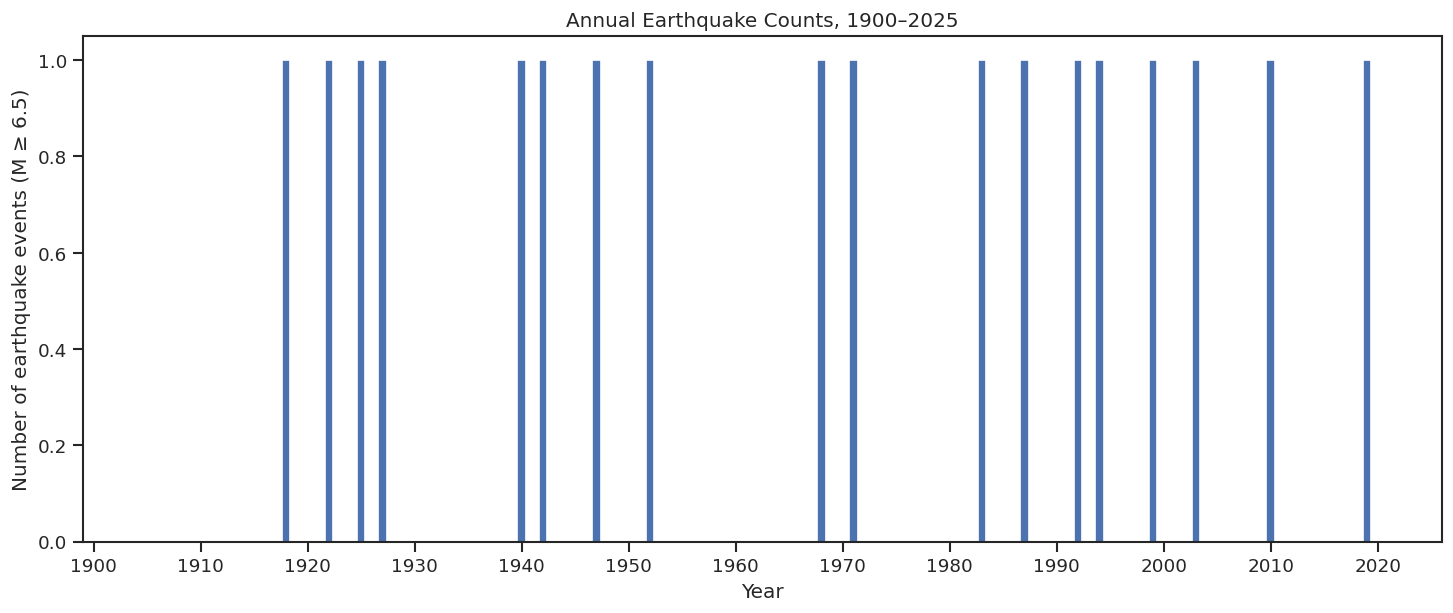

In [11]:


# ---------------------------------------------------------
# 1. EVENT IDs
# ---------------------------------------------------------
print("===== EVENT ID =====")
print("Total rows:", len(events))
print("Missing IDs:", events["id"].isna().sum())
print("Unique IDs:", events["id"].nunique())
print("IDs unique:", events["id"].is_unique)
print("Duplicate IDs:", events["id"].duplicated().sum())

# ---------------------------------------------------------
# 2. MISSING VALUES
# ---------------------------------------------------------
print("\n===== MISSING VALUES (per column) =====")
print(events.isna().sum())

print("\nMissing in columns used by the annual-count likelihood (time):",
      events["time"].isna().sum())
print("Missing in columns used by the frozen-extract audit "
      "(id, time, mag, latitude, longitude):",
      events[["id", "time", "mag", "latitude", "longitude"]].isna().sum().sum())
print("Missing in columns used by neither (depth, place):",
      events[["depth", "place"]].isna().sum().sum())

rows_with_na = events[events.isna().any(axis=1)]
print(f"\nRows with at least one missing value: {len(rows_with_na)}")
print(rows_with_na[["id", "time", "mag", "depth", "place"]].to_string())

# ---------------------------------------------------------
# 3. QUERY FILTERS (NaN counted as a violation in every check)
# ---------------------------------------------------------
print("\n===== QUERY FILTERS =====")
start_time = pd.Timestamp("1900-01-01", tz="UTC")
end_time = pd.Timestamp("2025-12-31 23:59:59.999999999", tz="UTC")

print("Magnitude < 6.5 (or missing):",
      (~(events["mag"] >= 6.5)).sum())
print("Latitude outside [32, 37]:",
      (~events["latitude"].between(32, 37)).sum())
print("Longitude outside [-122, -114]:",
      (~events["longitude"].between(-122, -114)).sum())
print("Time outside [1900-01-01, 2025-12-31]:",
      (~events["time"].between(start_time, end_time)).sum())

print("\nObserved ranges:")
print("  time :", events["time"].min(), "to", events["time"].max())
print("  mag  :", events["mag"].min(), "to", events["mag"].max())
print("  lat  :", events["latitude"].min(), "to", events["latitude"].max())
print("  lon  :", events["longitude"].min(), "to", events["longitude"].max())

# ---------------------------------------------------------
# 4. ANNUAL COUNTS
# ---------------------------------------------------------
print("\n===== ANNUAL COUNTS =====")
print("Total events (sum of annual counts):", annual_counts.sum())
print("Consistent with number of rows:", annual_counts.sum() == len(events))
print("Zero-event years:", (annual_counts == 0).sum())
print("Years with at least one event:", (annual_counts > 0).sum())
print("Maximum annual count:", annual_counts.max())
print("Year(s) of maximum:", YEARS[annual_counts == annual_counts.max()].tolist())
print("Mean annual count:", round(annual_counts.mean(), 4))

# ---------------------------------------------------------
# 5. EXPOSURE
# ---------------------------------------------------------
print("\n===== EXPOSURE =====")
print("Number of years:", len(YEARS))
print("Total exposure:", EXPOSURE_YEARS, "years")

# ---------------------------------------------------------
# 6. PLOT
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.bar(YEARS, annual_counts)
#plt.axhline(annual_counts.mean(), color="red", linestyle="--",
#            label=f"Mean = {annual_counts.mean():.3f} events/yr")
plt.xlabel("Year")
plt.ylabel("Number of earthquake events (M ≥ 6.5)")
plt.title("Annual Earthquake Counts, 1900–2025")
plt.xlim(1899, 2026)
plt.xticks(np.arange(1900, 2026, 10))
#plt.legend()
#plt.tight_layout()
plt.show()

## 2.1 Audit and Representation of the Observations

**Event identifiers.** The frozen extract has 18 rows, with 0 missing IDs and 18 distinct IDs (0 duplicates). Every row is therefore a distinct catalog event, and no event is double-counted.

**Query window, magnitude threshold, and geographic bounds.** All checks returned zero violations:

| Filter | Required | Observed | Violations |
|---|---|---|---|
| Time | 1900-01-01 to 2025-12-31 | 1918-04-21 to 2019-07-06 | 0 |
| Magnitude | $M \ge 6.5$ | 6.5 to 7.5 | 0 |
| Latitude | $32^\circ \le \phi \le 37^\circ$ N | 32.29 to 36.23 | 0 |
| Longitude | $-122^\circ \le \theta \le -114^\circ$ | -121.10 to -115.30 | 0 |

The extract is consistent with its stated query. The minimum magnitude equals the threshold exactly (6.5), so the comparison must use $\ge$.

**Missingness.** Only one value in the whole table is missing: `depth` for the 1922 Parkfield event (`ushis675`). This affects neither the likelihood nor the audit:

- The annual-count likelihood uses only the calendar year taken from `time`, which has 0 missing values.
- The frozen-extract audit uses `id`, `time`, `mag`, `latitude`, and `longitude`, all with 0 missing values. Depth is not part of the query filter.

**Summary of the annual counts** ($t = 1900, \dots, 2025$):

| Quantity | Value |
|---|---|
| Total events, $n = \sum_t y_t$ | 18 (matches the number of rows) |
| Zero-event years | 108 of 126 |
| Years with one event | 18 |
| Maximum annual count | 1 (attained in 18 different years) |
| Total exposure, $E = \sum_t \Delta t$ | 126 years |
| Sample mean rate, $n/E$ | $18/126 \approx 0.143$ events/year |

Every year has either 0 or 1 event, so the counts are effectively a 0/1 sequence. The plot shows 18 isolated single-event years (1918 to 2019); the first 18 years, 1900 to 1917, contain no events.





## Why zero-event years must remain in the exposure and likelihood

Under the model $Y_t \mid \lambda \sim \text{Poisson}(\lambda \Delta t)$ with $\Delta t = 1$, a year with $y_t = 0$ contributes the likelihood factor

$$
P(Y_t = 0 \mid \lambda) = e^{-\lambda \Delta t} = e^{-\lambda},
$$

which is not equal to 1. A quiet year is therefore evidence that $\lambda$ is small. Over all 126 years,

$$
L(\lambda) \propto \prod_{t} \lambda^{y_t} e^{-\lambda} = \lambda^{18} e^{-126\lambda},
$$

so the total exposure is $E = 126$ years, not 18, and the posterior is

$$
\lambda \mid y \sim \text{Gamma}(\alpha_0 + 18,\ \beta_0 + 126).
$$

If the 108 zero-event years were dropped, we would have 18 events in 18 years and a rate estimate near 1 event/year. With all 126 years the estimate is $18/126 \approx 0.143$ events/year, about seven times smaller. The catalog lists only events that occurred, but a year with no listed event is not missing data. It is an observed year with a known count of zero, and it must stay in both the exposure $E$ and the likelihood.

## Catalog-specific limitation: temporal heterogeneity of the catalog

Exchangeability means the joint model is unchanged if the annual observations are permuted, which rules out any systematic dependence of the rate on calendar year. The catalog may violate this because its quality changes over time. The event IDs come from different sources historical and early-instrumental compilations for older events, and a modern regional network for recent ones. Early magnitudes are less precise and were estimated by different methods. Because the threshold is sharp ($M \ge 6.5$), an event whose true magnitude is near 6.5 (the 1922 Parkfield event is exactly 6.50) could fall on either side of it depending on the era. If that happens more often in some periods than others, the effective rate depends on calendar year and the constant-$\lambda$, exchangeable model is only an approximation.

The empty stretch 1900 to 1917 is suggestive but not conclusive: under the constant-rate model with $\lambda \approx 0.143$, the probability of 18 consecutive empty years is $e^{-18(0.143)} \approx 0.08$, unusual but not impossible.

### 2.2 Prior information and sensitivity (15 points)

Compare these Gamma shape-rate priors for $\lambda$:

- **Maximum-entropy mean-only:** $\operatorname{Gamma}(1,8)$; positive
  support, mean $0.125$ events/year, and no other quantitative constraint
  relative to $q(\lambda)=1$ with respect to $d\lambda$ in the stated
  events/year coordinate.
- **Same-mean concentrated:** $\operatorname{Gamma}(4,32)$; hypothetical
  stronger prior information with the same mean.
- **Lower-rate sensitivity:** $\operatorname{Gamma}(2,40)$; hypothetical
  alternative with mean $0.05$ events/year.

Report each prior mean, standard deviation, and central 90% interval in
events/year. Plot all three densities on a common, readable rate range.
Explain why the first prior is exponential and how the first two priors can
have the same mean but express different information.


       Prior  Shape (alpha)  Rate (beta)     Mean       SD  5th percentile  95th percentile
 Gamma(1, 8)              1            8 0.125000 0.125000        0.006412         0.374467
Gamma(4, 32)              4           32 0.125000 0.062500        0.042697         0.242302
Gamma(2, 40)              2           40 0.050000 0.035355        0.008884         0.118597


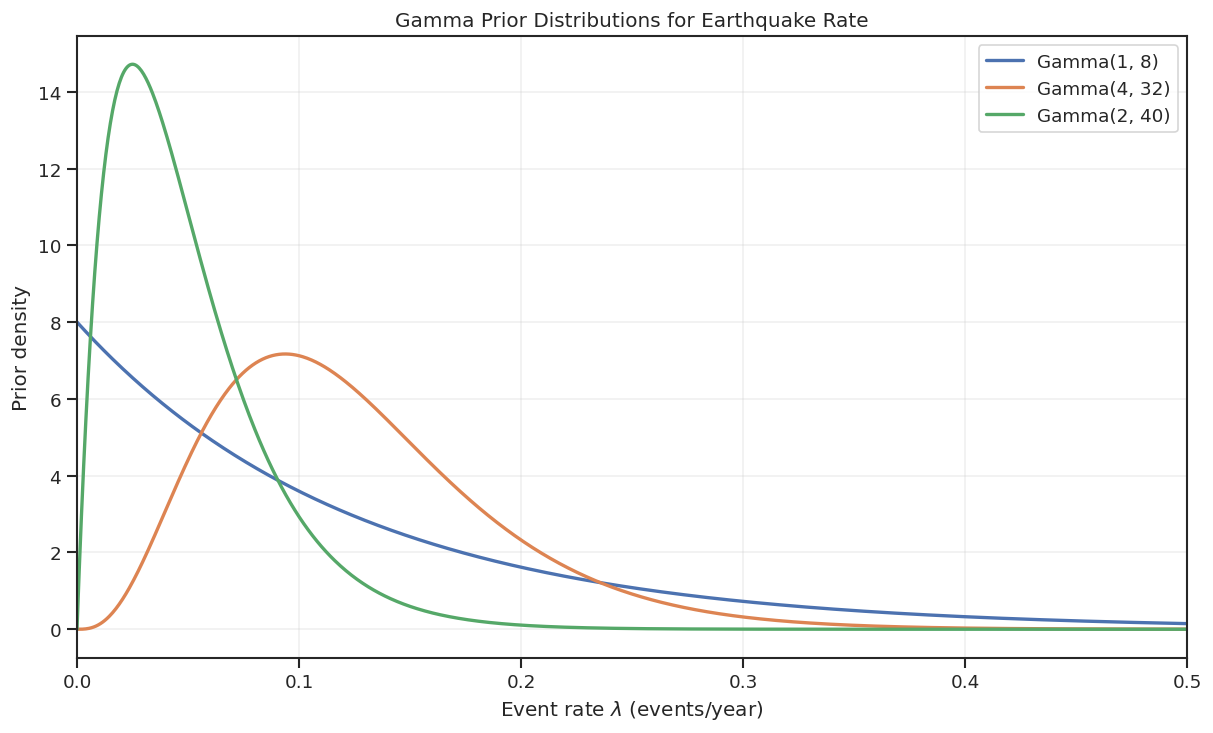

In [14]:

priors = {
    "Gamma(1, 8)":  (1, 8),
    "Gamma(4, 32)": (4, 32),
    "Gamma(2, 40)": (2, 40)
}

results = []

for name, (alpha, beta) in priors.items():

    # Mean and standard deviation for Gamma(shape, rate)
    mean = alpha / beta
    sd = np.sqrt(alpha) / beta

    # Central 90% interval: 5th and 95th percentiles
    q05, q95 = stats.gamma.ppf(
        [0.05, 0.95],
        a=alpha,
        scale=1 / beta
    )

    results.append({
        "Prior": name,
        "Shape (alpha)": alpha,
        "Rate (beta)": beta,
        "Mean": mean,
        "SD": sd,
        "5th percentile": q05,
        "95th percentile": q95
    })

prior_summary = pd.DataFrame(results)

print(prior_summary.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


lambda_grid = np.linspace(0, 0.5, 1000)

plt.figure(figsize=(10, 6))

for name, (alpha, beta) in priors.items():

    density = stats.gamma.pdf(
        lambda_grid,
        a=alpha,
        scale=1 / beta
    )

    plt.plot(
        lambda_grid,
        density,
        linewidth=2,
        label=name
    )

plt.xlabel(r"Event rate $\lambda$ (events/year)")
plt.ylabel("Prior density")
plt.title("Gamma Prior Distributions for Earthquake Rate")

plt.xlim(0, 0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Problem 2.2 — Prior Information and Sensitivity

The three priors use the shape-rate parameterization

$$
\lambda \sim \text{Gamma}(\alpha,\beta),
$$

for which

$$
E[\lambda]=\frac{\alpha}{\beta},
\qquad
SD(\lambda)=\frac{\sqrt{\alpha}}{\beta}.
$$

The resulting prior summaries are:

| Prior        | Mean (events/year) | SD (events/year) | Central 90% interval (events/year) |
| ------------ | -----------------: | ---------------: | ---------------------------------: |
| Gamma(1, 8)  |           0.125000 |         0.125000 |               [0.006412, 0.374467] |
| Gamma(4, 32) |           0.125000 |         0.062500 |               [0.042697, 0.242302] |
| Gamma(2, 40) |           0.050000 |         0.035355 |               [0.008884, 0.118597] |

**Why the first prior is exponential.** Among all densities on $\lambda>0$ with a specified mean $m$, the maximum-entropy density relative to the flat reference measure $q(\lambda)=1$ in the events/year coordinate has the form

$$
p(\lambda)\propto q(\lambda)e^{-\theta\lambda}=e^{-\theta\lambda},
$$

where $\theta$ is the Lagrange multiplier associated with the mean constraint. Matching

$$
E[\lambda]=\frac{1}{\theta}=0.125
$$

gives $\theta=8$, so

$$
p(\lambda)=8e^{-8\lambda}.
$$

This is the exponential distribution with rate 8, which is exactly $\text{Gamma}(1,8)$. Its mean and standard deviation are both $1/8=0.125$ events/year.

**Same mean, different information.** Gamma(1, 8) and Gamma(4, 32) have the same prior mean,

$$
\frac{1}{8}=\frac{4}{32}=0.125
$$

events/year, but they encode different amounts of prior information. Gamma(4, 32) has half the standard deviation (0.0625 versus 0.125) and a much narrower central 90% interval. Therefore, it places more probability near its mean and less probability in the tails.

In the Gamma–Poisson model, the parameters can also be interpreted using a pseudo-count representation: Gamma(1, 8) corresponds to 1 prior event over 8 years, while Gamma(4, 32) corresponds to 4 prior events over 32 years. Both imply the same prior rate, but the latter represents stronger prior concentration around that rate. Thus, the two priors have the same mean but do not represent the same amount of prior information. Since

$$
\beta_N=\beta_0+E,
$$

the more concentrated Gamma(4, 32) prior will have a stronger influence on the posterior than Gamma(1, 8), although the 126 years of observed exposure will also contribute substantial information.

**Lower-rate sensitivity prior.** Gamma(2, 40) has a mean of 0.05 events/year, corresponding to approximately one event every 20 years. Its standard deviation is 0.035355 events/year, with central 90% interval

$$
[0.008884,\;0.118597]\text{ events/year}.
$$

The observed sample rate is

$$
\frac{18}{126}\approx0.1429\text{ events/year},
$$

which is above the prior's 95th percentile (0.118597 events/year). Therefore, Gamma(2, 40) represents a deliberately lower-rate prior and provides a useful sensitivity test for how the posterior changes when the prior assumption is shifted away from the observed sample rate.

**Plot interpretation.** Gamma(1, 8) is monotonically decreasing from density 8 at $\lambda=0$ and has a long right tail. Gamma(4, 32) is more concentrated, with an interior mode near 0.094 events/year. Gamma(2, 40) is centered at a lower rate, with its mode near 0.025 events/year. The plot therefore illustrates both the effect of changing prior concentration while keeping the same mean and the effect of shifting the prior mean to a lower event rate.


### 2.3 Posterior inference, credible intervals, and Bayes actions (20 points)

Implement the supplied Gamma–Poisson update using total count and total exposure.
For each prior, report the posterior shape and rate, mean, median, mode, and
central 95% credible interval for $\lambda$. Express rate summaries in both
events/year and events/decade. Plot the three posterior densities.

State which point summary is the Bayes action under squared-error loss and
which is the Bayes action under absolute-error loss. Report the continuous
posterior mode only as a density summary; do not use exact 0–1 loss to justify
it for a continuous parameter.


Total count n = 18
Total exposure E = 126 years

===== POSTERIOR SUMMARY =====
       Prior  Posterior shape  Posterior rate  Mean (yr^-1)  Median (yr^-1)  Mode (yr^-1)  2.5% (yr^-1)  97.5% (yr^-1)  Mean (decade^-1)  Median (decade^-1)  Mode (decade^-1)  2.5% (decade^-1)  97.5% (decade^-1)
 Gamma(1, 8)               19             134      0.141791        0.139311      0.134328      0.085367       0.212297          1.417910            1.393114          1.343284          0.853675           2.122967
Gamma(4, 32)               22             158      0.139241        0.137137      0.132911      0.087261       0.203169          1.392405            1.371366          1.329114          0.872613           2.031692
Gamma(2, 40)               20             166      0.120482        0.118480      0.114458      0.073593       0.178740          1.204819            1.184800          1.144578          0.735935           1.787401


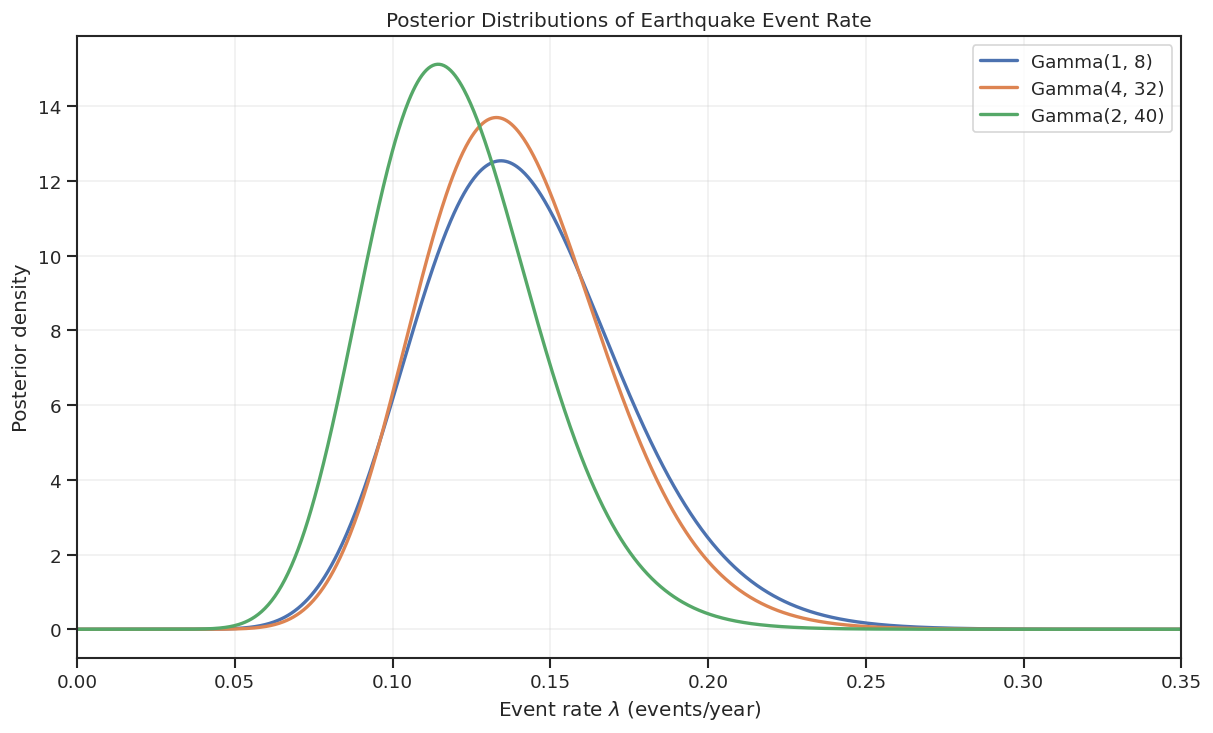

In [18]:
def gamma_poisson_update(alpha, beta, counts, exposure_years):
    '''Return posterior shape and rate for a Gamma–Poisson rate model.'''
    # YOUR CODE HERE

    total_count = np.sum(counts)

    alpha_N = alpha + total_count
    beta_N = beta + exposure_years

    return alpha_N, beta_N


# ---------------------------------------------------------
# Observed data from Problem 2.1
# ---------------------------------------------------------
n = annual_counts.sum()       # total number of events
E = EXPOSURE_YEARS            # total exposure in years

print("Total count n =", n)
print("Total exposure E =", E, "years")


# ---------------------------------------------------------
# Priors from Problem 2.2
# ---------------------------------------------------------
priors = {
    "Gamma(1, 8)":  (1, 8),
    "Gamma(4, 32)": (4, 32),
    "Gamma(2, 40)": (2, 40)
}


# ---------------------------------------------------------
# Calculate posterior summaries
# ---------------------------------------------------------
posterior_results = []

for name, (alpha_0, beta_0) in priors.items():

    # Gamma-Poisson update
    alpha_N, beta_N = gamma_poisson_update(
        alpha_0, beta_0, annual_counts, E
    )

    # Posterior mean
    mean = alpha_N / beta_N

    # Posterior median
    median = stats.gamma.ppf(
        0.5,
        a=alpha_N,
        scale=1 / beta_N
    )

    # Posterior mode
    mode = (alpha_N - 1) / beta_N

    # Central 95% credible interval
    q025, q975 = stats.gamma.ppf(
        [0.025, 0.975],
        a=alpha_N,
        scale=1 / beta_N
    )

    posterior_results.append({
        "Prior": name,
        "Posterior shape": alpha_N,
        "Posterior rate": beta_N,
        "Mean (yr^-1)": mean,
        "Median (yr^-1)": median,
        "Mode (yr^-1)": mode,
        "2.5% (yr^-1)": q025,
        "97.5% (yr^-1)": q975,
        "Mean (decade^-1)": 10 * mean,
        "Median (decade^-1)": 10 * median,
        "Mode (decade^-1)": 10 * mode,
        "2.5% (decade^-1)": 10 * q025,
        "97.5% (decade^-1)": 10 * q975
    })


# ---------------------------------------------------------
# Posterior summary table
# ---------------------------------------------------------
posterior_summary = pd.DataFrame(posterior_results)

print("\n===== POSTERIOR SUMMARY =====")
print(
    posterior_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


# ---------------------------------------------------------
# Plot posterior densities
# ---------------------------------------------------------
lambda_grid = np.linspace(0, 0.35, 1000)

plt.figure(figsize=(10, 6))

for name, (alpha_0, beta_0) in priors.items():

    alpha_N, beta_N = gamma_poisson_update(
        alpha_0, beta_0, annual_counts, E
    )

    density = stats.gamma.pdf(
        lambda_grid,
        a=alpha_N,
        scale=1 / beta_N
    )

    plt.plot(
        lambda_grid,
        density,
        linewidth=2,
        label=name
    )

plt.xlabel(r"Event rate $\lambda$ (events/year)")
plt.ylabel("Posterior density")
plt.title("Posterior Distributions of Earthquake Event Rate")
plt.xlim(0, 0.35)
plt.legend()
plt.grid(alpha=0.3)
#plt.tight_layout()
plt.show()
#raise NotImplementedError


# Use the function above to build a posterior summary and density plot.
# YOUR CODE HERE



Using the Gamma–Poisson conjugate update,

$$
\alpha_N=\alpha_0+n,
\qquad
\beta_N=\beta_0+E,
$$

with total observed count $n=18$ and total exposure $E=126$ years, the posterior distribution for each prior is

$$
\lambda\mid y \sim \text{Gamma}(\alpha_N,\beta_N).
$$

The posterior summaries are:

| Prior | Posterior shape | Posterior rate | Mean ($\text{yr}^{-1}$) | Median ($\text{yr}^{-1}$) | Mode ($\text{yr}^{-1}$) | Central 95% CI ($\text{yr}^{-1}$) |
|---|---:|---:|---:|---:|---:|---:|
| Gamma(1, 8) | 19 | 134 | 0.141791 | 0.139311 | 0.134328 | [0.085367, 0.212297] |
| Gamma(4, 32) | 22 | 158 | 0.139241 | 0.137137 | 0.132911 | [0.087261, 0.203169] |
| Gamma(2, 40) | 20 | 166 | 0.120482 | 0.118480 | 0.114458 | [0.073593, 0.178740] |

Expressed as events per decade:

| Prior | Mean ($\text{decade}^{-1}$) | Median ($\text{decade}^{-1}$) | Mode ($\text{decade}^{-1}$) | Central 95% CI ($\text{decade}^{-1}$) |
|---|---:|---:|---:|---:|
| Gamma(1, 8) | 1.417910 | 1.393114 | 1.343284 | [0.853675, 2.122967] |
| Gamma(4, 32) | 1.392405 | 1.371366 | 1.329114 | [0.872613, 2.031692] |
| Gamma(2, 40) | 1.204819 | 1.184800 | 1.144578 | [0.735935, 1.787401] |

The posterior mean is a weighted average of the prior mean and the sample rate $n/E=18/126\approx 0.142857$ events/year:

$$
E[\lambda\mid y]=\frac{\beta_0}{\beta_N}\cdot\frac{\alpha_0}{\beta_0}+\frac{E}{\beta_N}\cdot\frac{n}{E}.
$$

The 126 years of exposure outweigh the prior pseudo-exposure of 8, 32, and 40 years, so the prior's share is only about 6%, 20%, and 24% respectively. Consequently, the posterior means for Gamma(1, 8) and Gamma(4, 32) (0.141791 and 0.139241 events/year) lie very close to the sample rate. Although these two priors have the same mean, the more concentrated Gamma(4, 32) prior yields a somewhat narrower 95% credible interval (width about 0.116 versus 0.127 events/year). The lower-rate prior Gamma(2, 40) pulls the posterior mean down to 0.120482 events/year, about 0.2 events/decade below the others, which shows the sensitivity of the posterior to the prior; nevertheless its interval still contains the sample rate.

In all three cases the posterior is right-skewed, so mode < median < mean. Each central 95% credible interval means that, given the model and prior, the posterior probability that $\lambda$ lies in the interval is 0.95, with 2.5% in each tail. The three posterior densities in the plot overlap substantially, and all place the event rate at roughly 1.2 to 1.4 events per decade, so the conclusion is fairly robust to these prior choices.

### Bayes actions

Under **squared-error loss**,

$$
L(\hat{\lambda},\lambda)=(\hat{\lambda}-\lambda)^2,
$$

the Bayes action is the **posterior mean**:

$$
\boxed{\hat{\lambda}_{\mathrm{SE}}=E[\lambda\mid y]}.
$$

Under **absolute-error loss**,

$$
L(\hat{\lambda},\lambda)=|\hat{\lambda}-\lambda|,
$$

the Bayes action is the **posterior median**:

$$
\boxed{\hat{\lambda}_{\mathrm{AE}}=\operatorname{median}(\lambda\mid y)}.
$$

The posterior mode is

$$
\operatorname{mode}(\lambda\mid y)=\frac{\alpha_N-1}{\beta_N},
$$

since all three posterior shape parameters exceed 1. The mode is reported here as a **density summary** indicating the location of the peak of the continuous posterior density. It is not justified as a Bayes action using exact 0–1 loss, which is not appropriate for a continuous parameter.


### 2.4 Posterior-predictive model check (15 points)

Use the maximum-entropy prior's posterior for this check. Generate 50,000
replicated 126-year catalogs by repeating these two steps for each catalog:

1. draw $\lambda^{\mathrm{rep}}$ from the posterior;
2. draw 126 conditionally independent annual counts from
   $\operatorname{Poisson}(\lambda^{\mathrm{rep}})$.

Each replication is a synthetic 126-year catalog generated under the
posterior-predictive model. The sampled rate $\lambda^{\mathrm{rep}}$ remains
fixed across all 126 years within that catalog and is redrawn for the next
catalog. Variation in $\lambda^{\mathrm{rep}}$ across catalogs propagates
posterior uncertainty about the unknown rate; the Poisson draws represent
year-to-year count variability at a fixed rate.

Define the discrepancy

$$
T(\mathbf y)=\frac{s_y^2}{\bar y},
$$

where $s_y^2$ is the sample variance across years. The discrepancy compares
the across-year variability of the counts with their average annual level.
A Poisson random variable has variance equal to its mean, so $T=1$ is the
natural reference. Values above 1 indicate **overdispersion**, and values
below 1 indicate **underdispersion**. For a finite, sparse catalog, compare
the observed value with its posterior-predictive distribution rather than
judging it against 1 alone.

In this snapshot every observed annual count is either 0 or 1. Before
simulating, show that if $N>1$ and $1\leq n\leq N$ events occur across $N$
such annual counts, then

$$
T(\mathbf y)=\frac{N-n}{N-1}.
$$

Explain one kind of temporal behavior that this observed statistic cannot
detect.

The statistic is undefined for a replicated catalog whose total count is
zero. Exclude any such catalog and report how many were excluded. Report the
observed value and, conditional on a positive replicated total, the central
95% posterior-predictive interval for $T$ and the Bayesian tail area

$$
P\left(
T(\mathbf Y^{\mathrm{rep}})\geq T(\mathbf y)
\mid
\mathbf y,\,
\sum_tY_t^{\mathrm{rep}}>0
\right).
$$

Plot the replicated discrepancy distribution with the observed value marked.
Interpret what the check can and cannot establish about the homogeneous
Poisson model.


Posterior shape: 19
Posterior rate: 134
Posterior mean: 0.1417910447761194
Observed T: 0.8640000000000003
0/1 formula T: 0.864
Formula agrees: True
Shape: (50000, 126)
Excluded catalogs: 0
Retained catalogs: 50000
Observed T: 0.864000
Central 95% posterior-predictive interval: [0.840000, 1.291200]
Bayesian tail area P(T_rep >= T_obs | y, total > 0): 0.928180


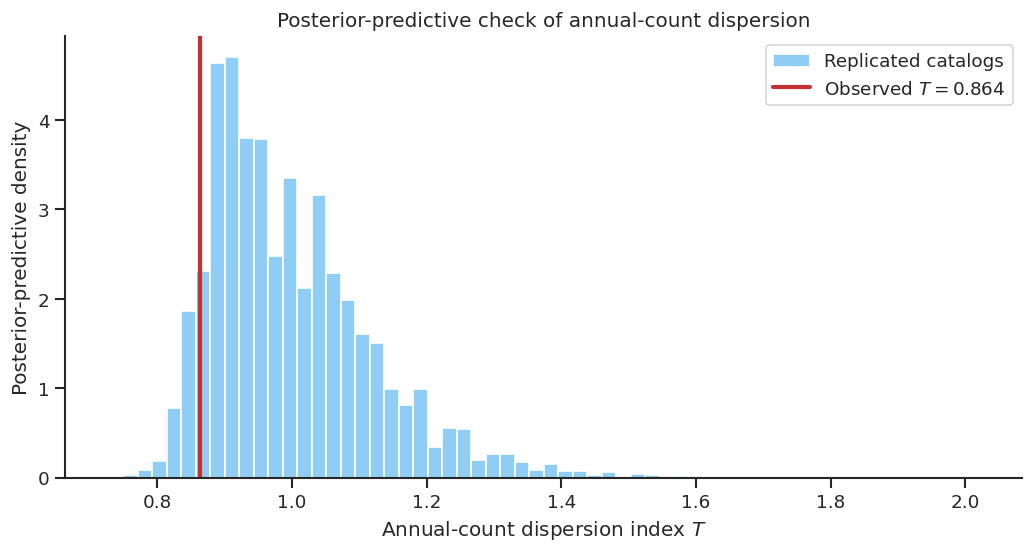

In [21]:
def simulate_replicated_catalogs(
    alpha_post,
    beta_post,
    n_years,
    n_replications=50_000,
    seed=SEED,
):
    '''Draw replicated annual-count catalogs from the posterior predictive.'''
    # Return an array with shape (n_replications, n_years).
    # YOUR CODE HERE
    rng = np.random.default_rng(seed)
    lambda_rep = rng.gamma(
        shape=alpha_post,
        scale=1 / beta_post,
        size=n_replications
    )
    replicated_counts = rng.poisson(
      lam=lambda_rep[:, None],
      size=(n_replications, n_years)
    )

    return replicated_counts


def dispersion_index(count_matrix):
    '''Return sample-variance/mean along the final axis.'''
    # For a two-dimensional input, return one discrepancy per row.
    # YOUR CODE HERE
    mean_counts = np.mean(count_matrix, axis=-1)
    sample_variance = np.var(count_matrix, axis=-1, ddof=1)

    return sample_variance / mean_counts


# Carry out the posterior-predictive calculation. Store the retained
# positive-total replicated discrepancies in finite_discrepancies and define
# observed_discrepancy, excluded_discrepancies, predictive_interval, and
# bayesian_tail_area. Use the same retained sample for the interval, tail
# area, and plot.
# YOUR CODE HERE
alpha_0 = 1
beta_0 = 8

alpha_post, beta_post = gamma_poisson_update(
    alpha_0,
    beta_0,
    annual_counts,
    EXPOSURE_YEARS
)
print("Posterior shape:", alpha_post)
print("Posterior rate:", beta_post)
print("Posterior mean:", alpha_post / beta_post)

observed_discrepancy = dispersion_index(
    annual_counts.reshape(1, -1)
)[0]

print("Observed T:", observed_discrepancy)

# Verify the special 0/1 formula
N = len(annual_counts)
n = annual_counts.sum()

formula_T = (N - n) / (N - 1)

print("0/1 formula T:", formula_T)
print("Formula agrees:", np.isclose(observed_discrepancy, formula_T))

replicated_catalogs = simulate_replicated_catalogs(
    alpha_post=alpha_post,
    beta_post=beta_post,
    n_years=EXPOSURE_YEARS,
    n_replications=50_000,
    seed=SEED
)

print("Shape:", replicated_catalogs.shape)

replicated_totals = replicated_catalogs.sum(axis=1)

positive_total = replicated_totals > 0

excluded_discrepancies = np.sum(~positive_total)

positive_catalogs = replicated_catalogs[positive_total]

print("Excluded catalogs:", excluded_discrepancies)
print("Retained catalogs:", positive_catalogs.shape[0])


finite_discrepancies = dispersion_index(positive_catalogs)

predictive_interval = np.quantile(
    finite_discrepancies,
    [0.025, 0.975]
)

bayesian_tail_area = np.mean(
    finite_discrepancies >= observed_discrepancy
)

print(f"Observed T: {observed_discrepancy:.6f}")

print(
    "Central 95% posterior-predictive interval:",
    f"[{predictive_interval[0]:.6f}, "
    f"{predictive_interval[1]:.6f}]"
)

print(
    "Bayesian tail area P(T_rep >= T_obs | y, total > 0):",
    f"{bayesian_tail_area:.6f}"
)

# Visualization code is supplied; it uses the quantities computed above.
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(
    finite_discrepancies,
    bins=60,
    density=True,
    color="#90cdf4",
    edgecolor="white",
    label="Replicated catalogs",
)
ax.axvline(
    observed_discrepancy,
    color="#c53030",
    linewidth=2.5,
    label=fr"Observed $T={observed_discrepancy:.3f}$",
)
ax.set(
    xlabel=r"Annual-count dispersion index $T$",
    ylabel="Posterior-predictive density",
    title="Posterior-predictive check of annual-count dispersion",
)
ax.legend()
sns.despine(ax=ax)
plt.show()


> **Response:** Replace this text with your posterior-predictive interpretation.


### 2.5 Ten- and twenty-year probabilities, sensitivity, and communication (15 points)

For each prior, calculate the exact posterior-predictive probabilities
$P(Y_*\ge1\mid\mathbf y)$ for $T=10$ and $T=20$ years. Compare each exact
value with the plug-in approximation

$$
1-\exp[-\mathbb{E}(\lambda\mid\mathbf y)T].
$$

A hypothetical preparedness rule triggers an action when the exact 20-year
probability is at least $0.90$. State the decision under each prior.

Then write 150–200 words for a technically literate decision maker. Your
explanation must distinguish expected count from probability of at least one
event, report the prior-sensitivity ranges for both the 10- and 20-year
horizons, state the action-rule result, and
identify at least two concrete limitations—one catalog-specific and one
model-specific. Do not present this calculation as an official forecast.


In [ ]:
# YOUR CODE HERE


> **Response (150–200 words):** Replace this text with your probability communication.


## Problem 2 data source and credit

The automatically loaded CSV is a frozen extract from the U.S. Geological Survey's
[ANSS Comprehensive Earthquake Catalog (ComCat)](https://earthquake.usgs.gov/data/comcat/)
([catalog DOI 10.5066/F7MS3QZH](https://doi.org/10.5066/F7MS3QZH)), queried
through the official [FDSN event web service](https://earthquake.usgs.gov/fdsnws/event/1/).
The [exact query](https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=1900-01-01&endtime=2026-01-01&minlatitude=32&maxlatitude=37&minlongitude=-122&maxlongitude=-114&minmagnitude=6.5&orderby=time-asc)
requested CSV output, start time `1900-01-01`, end time `2026-01-01`,
latitude 32–37 degrees N, longitude −122 to −114 degrees, minimum magnitude
6.5, and ascending event time. The snapshot was retrieved August 17, 2026;
only `time`, `latitude`, `longitude`, `depth`, `mag`, `place`, and `id` were
retained and sorted by time.

**Frozen-file SHA-256:**
`a4e7fb0d2a99fc81cf0f309e13a853b6025413e84d61ab82f18cc8c43ec37072`.

The Bayesian Poisson treatment of uncertain earthquake rates and future
occurrence probabilities is informed by
[Love (2012)](https://pubs.usgs.gov/publication/70045154) and
[Rotondi (2013)](https://academic.oup.com/gji/article/195/1/381/599171).
The frozen California–Baja snapshot, prior-information exercise,
posterior-predictive check, and 10/20-year comparison were assembled for
this assignment.

The setup cell first accepts a matching local course copy and otherwise
downloads the frozen
[Homework 3 course-data file](../data/homework/southern-california-baja-earthquakes-1900-2025.csv).
It verifies the bytes against the checksum before parsing them. The USGS
query above documents provenance only; this notebook never executes that
mutable live query.

USGS catalogs can be revised. This fixed file is used for reproducibility.
The reported quantity is a **model-based probability of at least one catalog
event under the constant-rate Poisson model**, not earthquake risk or an
authoritative California forecast. For California's scientific long-term
forecast resources, see the
[California Geological Survey's UCERF page](https://www.conservation.ca.gov/cgs/Pages/Earthquakes/UCERF3.aspx).

## Submission checklist

- Both numbered problems total 100 points.
- Every code cell runs from top to bottom and the setup reports a verified
  data source; no manual data upload is required.
- All figures have labels and units.
- The 150–200 word communication is included.
- No response cell still contains placeholder text.
